# NBA Head-to-Head Predictions

This notebook combines:
1. **Baselines** — simple rule-based predictors for the NBA game-outcome task
2. **Models** — Random Forest, Extra Trees, and XGBoost classifiers, evaluated via walk-forward CV

# Part 1: Baselines

## Setting: home team win = 1, home team loss = 0

## Two baseline models: 

1. Home team always wins. 
Accuracy: 57.36%

2. Teams with better records of the last 10 games win; if same record, then home team wins.
Accuracy: 61.44%

## Setup

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import accuracy_score, roc_auc_score


In [90]:
# Load matchup-level dataset (rolling-window / record-based features)
prefix = "../data/processed/"
matchups = pd.read_csv(prefix + 'TeamStatisticsFrom2010RPMatchups.csv')

In [91]:
# Inspect the dataframe
matchups

,gameId,gameDate,season,win,home_teamId,home_teamName,home_rest_days,home_b2b,home_teamScore_roll10,home_fieldGoalsPercentage_roll10,...,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
0,21000031,2010-10-30,2010,1,1610612737,Hawks,0.0,1,111.500000,0.519500,...,6.500000,13.500000,5.000000,4.500000,-5.000000,5.500000,38.000000,1.000000,-1.0,1
1,21000054,2010-11-03,2010,1,1610612737,Hawks,0.0,1,105.500000,0.474750,...,-0.500000,4.000000,6.250000,0.000000,0.750000,2.250000,17.750000,1.000000,0.0,0
2,21000090,2010-11-07,2010,0,1610612737,Hawks,1.0,0,104.833333,0.496500,...,-4.100000,4.033333,3.700000,-2.333333,-3.166667,1.700000,9.433333,0.600000,0.0,0
3,21000108,2010-11-10,2010,0,1610612737,Hawks,1.0,0,104.000000,0.499375,...,-1.000000,1.250000,6.625000,-0.500000,-1.000000,2.750000,5.250000,0.375000,1.0,-1
4,21000121,2010-11-12,2010,0,1610612737,Hawks,1.0,0,102.555556,0.498667,...,-0.819444,0.402778,-0.819444,-0.888889,-2.361111,0.694444,2.236111,0.041667,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20496,22501085,2026-03-29,2025,0,1610612766,Hornets,0.0,1,117.300000,0.463500,...,1.200000,-2.500000,1.400000,1.700000,1.000000,1.200000,5.600000,0.000000,-1.0,1
20497,22501114,2026-04-02,2025,1,1610612766,Hornets,1.0,0,118.700000,0.473400,...,-0.400000,3.300000,-0.800000,2.300000,-2.200000,-1.200000,9.800000,0.400000,0.0,0
20498,22501120,2026-04-03,2025,1,1610612766,Hornets,0.0,1,119.700000,0.479400,...,5.100000,2.600000,-8.700000,-0.200000,-0.100000,-0.700000,18.500000,0.400000,-1.0,1
20499,22501171,2026-04-10,2025,0,1610612766,Hornets,2.0,0,118.200000,0.476200,...,2.100000,1.500000,-5.800000,-2.500000,-3.500000,-3.000000,4.400000,0.000000,1.0,0


## Baseline 1: home team always wins
Simplest possible baseline — predict the home team wins every game.

In [92]:
# Home team's per-season win rate (sanity check that ~57% holds across seasons)
home_win_pct = []

for year in range(2015, 2026):
    
    home_win_pct.append({
        'Season': year, 
        'Accuracy': matchups[matchups['season'] == year]['win'].mean()})
    
home_win_pct_df = pd.DataFrame(home_win_pct)

# Save this baseline's per-season accuracy under its own name for the final summary table
home_team_win_acc = home_win_pct_df.set_index('Season')['Accuracy'].rename('home_team_win')

home_win_pct_df.round(4)


,Season,Accuracy
0,2015,0.5942
1,2016,0.5829
2,2017,0.5869
3,2018,0.5907
4,2019,0.5448
5,2020,0.5465
6,2021,0.5480
7,2022,0.5811
8,2023,0.5470
9,2024,0.5452


In [93]:
# Overall home win rate = accuracy of the "home team always wins" baseline
matchups['win'].mean()

np.float64(0.5745573386664066)

In [94]:
# if we blindly predict that home team wins for every game, then we have about 57.36% accuracy

## Baseline 2: better recent record wins
Predict the team with the better record over its last 10 games wins; ties go to the home team.

In [95]:
# win_roll10_diff = (home team's last-10-game win pct) - (away team's last-10-game win pct)
matchups['win_roll10_diff'].describe()

count    20501.000000
mean        -0.003454
std          0.291555
min         -1.000000
25%         -0.200000
50%          0.000000
75%          0.200000
max          1.000000
Name: win_roll10_diff, dtype: float64

In [96]:
# Distribution of the raw diff values
matchups['win_roll10_diff'].value_counts()

win_roll10_diff
 0.000000    2845
-0.100000    1929
 0.100000    1871
-0.300000    1273
 0.300000    1262
             ... 
 0.144444       1
-0.071429       1
 0.033333       1
 0.050000       1
-0.550000       1
Name: count, Length: 95, dtype: int64

In [97]:
# Distribution of the diff magnitudes (symmetry check)
matchups['win_roll10_diff'].abs().value_counts()

win_roll10_diff
0.100000    3800
0.000000    2845
0.300000    2535
0.200000    2269
0.200000    2058
            ... 
0.233333       1
0.095238       1
0.144444       1
0.033333       1
0.550000       1
Name: count, Length: 65, dtype: int64

In [98]:
# Predict home win whenever home's recent record is >= away's (ties -> home team)
matchups['pred_win'] = (matchups['win_roll10_diff'] >= 0) * 1.0

In [99]:
# Overall accuracy of the "better recent record wins" baseline
print(f"Accuracy: {accuracy_score(matchups['win'], matchups['pred_win']):.4f}")

Accuracy: 0.6202


In [100]:
# Per-season accuracy breakdown for this baseline
better_last10 = []

for year in range(2015, 2026):
    y_true = matchups[matchups['season'] == year]['win']
    y_pred = matchups[matchups['season'] == year]['pred_win']
    better_last10.append({
        'Season': year, 
        'Accuracy': accuracy_score(y_true=y_true, y_pred=y_pred)})
    
better_last10_df = pd.DataFrame(better_last10)

# Save this baseline's per-season accuracy under its own name (better_last10_df gets reused
# by the Random Forest section below, so capture what we need from it now)
better_last10_acc = better_last10_df.set_index('Season')['Accuracy'].rename('better_last10_win')

better_last10_df.round(4)


,Season,Accuracy
0,2015,0.6375
1,2016,0.6157
2,2017,0.6258
3,2018,0.6159
4,2019,0.6149
5,2020,0.5918
6,2021,0.6039
7,2022,0.5712
8,2023,0.6244
9,2024,0.6327


# Part 2: Models

In [101]:
# --- Additional models (numpy/pandas/plt/sns/accuracy_score already imported in Part 1) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

# --- Additional metrics & splitting ---
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split


## Load data

In [102]:
# Precomputed matchup-level datasets:
#   matchups    - raw home/away diff features
#   matchupsEWM - EWM-smoothed (halflife=3) diff features
prefix = "../data/processed/"
matchups = pd.read_csv(prefix + 'TeamStatisticsFrom2010RegMatchups.csv')
matchupsEWM = pd.read_csv(prefix + 'TeamStatisticsFrom2010RegEWMMatchups.csv')

## Data exploration
Quick sanity checks on the two datasets before modeling.

In [103]:
# Peek at available columns for the EWM dataset
matchupsEWM.columns

Index(['gameId', 'gameDate', 'season', 'win', 'home_teamId', 'home_teamName',
       'home_rest_days', 'home_b2b', 'home_teamScore_ewm3',
       'home_fieldGoalsPercentage_ewm3', 'home_threePointersPercentage_ewm3',
       'home_freeThrowsPercentage_ewm3', 'home_reboundsOffensive_ewm3',
       'home_reboundsDefensive_ewm3', 'home_assists_ewm3',
       'home_turnovers_ewm3', 'home_steals_ewm3', 'home_blocks_ewm3',
       'home_plusMinusPoints_ewm3', 'home_win_ewm3', 'away_teamId',
       'away_teamName', 'away_rest_days', 'away_b2b', 'away_teamScore_ewm3',
       'away_fieldGoalsPercentage_ewm3', 'away_threePointersPercentage_ewm3',
       'away_freeThrowsPercentage_ewm3', 'away_reboundsOffensive_ewm3',
       'away_reboundsDefensive_ewm3', 'away_assists_ewm3',
       'away_turnovers_ewm3', 'away_steals_ewm3', 'away_blocks_ewm3',
       'away_plusMinusPoints_ewm3', 'away_win_ewm3', 'teamScore_ewm3_diff',
       'fieldGoalsPercentage_ewm3_diff', 'threePointersPercentage_ewm3_diff',
     

In [104]:
# Inspect the EWM matchup dataframe
matchupsEWM

,gameId,gameDate,season,win,home_teamId,home_teamName,home_rest_days,home_b2b,home_teamScore_ewm3,home_fieldGoalsPercentage_ewm3,...,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
0,21000031,2010-10-30,2010,1,1610612737,Hawks,0.0,1,110.637400,0.518867,...,6.557507,13.557507,5.230027,4.787533,-5.230027,5.442493,37.309920,1.000000,-1.0,1
1,21000054,2010-11-03,2010,1,1610612737,Hawks,0.0,1,103.839755,0.465052,...,0.049218,3.233030,7.356594,-1.721738,1.055225,2.137340,19.712151,1.000000,0.0,0
2,21000090,2010-11-07,2010,0,1610612737,Hawks,1.0,0,104.211211,0.502200,...,-6.128261,3.302122,3.860234,-3.750170,-4.112765,1.587702,8.726075,0.548262,0.0,0
3,21000108,2010-11-10,2010,0,1610612737,Hawks,1.0,0,102.388979,0.503030,...,-1.400265,0.993729,6.638976,-0.514410,-1.718046,2.196203,-0.963421,0.084545,1.0,-1
4,21000121,2010-11-12,2010,0,1610612737,Hawks,1.0,0,99.703790,0.500665,...,-0.850847,-0.117101,-0.944605,0.439035,-2.327432,-0.151762,-5.017610,-0.339194,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19125,22501077,2026-03-28,2025,0,1610612766,Hornets,1.0,0,121.031826,0.493178,...,0.294500,0.659038,-0.410604,2.583391,-1.363041,-2.651783,16.673532,0.234393,-1.0,0
19126,22501085,2026-03-29,2025,0,1610612766,Hornets,0.0,1,119.581164,0.468798,...,1.682822,-2.844436,1.583070,0.919197,1.345959,0.272447,7.392949,-0.084712,-1.0,1
19127,22501114,2026-04-02,2025,1,1610612766,Hornets,1.0,0,115.678712,0.463554,...,-0.972843,2.583567,-2.598540,0.442209,-3.277080,-1.402419,4.638827,0.185555,0.0,0
19128,22501120,2026-04-03,2025,1,1610612766,Hornets,0.0,1,118.014287,0.474374,...,5.446841,1.649059,-11.082585,-1.357419,-1.212678,-0.915444,12.305771,0.257104,-1.0,1


In [105]:
# Inspect the raw (non-EWM) matchup dataframe
matchups

,gameId,gameDate,season,win,home_teamId,home_teamName,home_rest_days,home_b2b,home_teamScore_roll10,home_fieldGoalsPercentage_roll10,...,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
0,21000031,2010-10-30,2010,1,1610612737,Hawks,0.0,1,111.500000,0.519500,...,6.500000,13.500000,5.000000,4.500000,-5.000000,5.500000,38.000000,1.000000,-1.0,1
1,21000054,2010-11-03,2010,1,1610612737,Hawks,0.0,1,105.500000,0.474750,...,-0.500000,4.000000,6.250000,0.000000,0.750000,2.250000,17.750000,1.000000,0.0,0
2,21000090,2010-11-07,2010,0,1610612737,Hawks,1.0,0,104.833333,0.496500,...,-4.100000,4.033333,3.700000,-2.333333,-3.166667,1.700000,9.433333,0.600000,0.0,0
3,21000108,2010-11-10,2010,0,1610612737,Hawks,1.0,0,104.000000,0.499375,...,-1.000000,1.250000,6.625000,-0.500000,-1.000000,2.750000,5.250000,0.375000,1.0,-1
4,21000121,2010-11-12,2010,0,1610612737,Hawks,1.0,0,102.555556,0.498667,...,-0.819444,0.402778,-0.819444,-0.888889,-2.361111,0.694444,2.236111,0.041667,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19125,22501077,2026-03-28,2025,0,1610612766,Hornets,1.0,0,117.900000,0.468700,...,0.300000,0.500000,0.300000,1.700000,-2.000000,-2.100000,11.400000,0.100000,-1.0,0
19126,22501085,2026-03-29,2025,0,1610612766,Hornets,0.0,1,117.300000,0.463500,...,1.200000,-2.500000,1.400000,1.700000,1.000000,1.200000,5.600000,0.000000,-1.0,1
19127,22501114,2026-04-02,2025,1,1610612766,Hornets,1.0,0,118.700000,0.473400,...,-0.400000,3.300000,-0.800000,2.300000,-2.200000,-1.200000,9.800000,0.400000,0.0,0
19128,22501120,2026-04-03,2025,1,1610612766,Hornets,0.0,1,119.700000,0.479400,...,5.100000,2.600000,-8.700000,-0.200000,-0.100000,-0.700000,18.500000,0.400000,-1.0,1


In [106]:
# Engineered home-minus-away 'diff' features for the EWM dataset
features_diff_ewm = [c for c in matchupsEWM.columns if c.endswith('_diff')]
features_diff_ewm

['teamScore_ewm3_diff',
 'fieldGoalsPercentage_ewm3_diff',
 'threePointersPercentage_ewm3_diff',
 'freeThrowsPercentage_ewm3_diff',
 'reboundsOffensive_ewm3_diff',
 'reboundsDefensive_ewm3_diff',
 'assists_ewm3_diff',
 'turnovers_ewm3_diff',
 'steals_ewm3_diff',
 'blocks_ewm3_diff',
 'plusMinusPoints_ewm3_diff',
 'win_ewm3_diff',
 'rest_days_diff',
 'b2b_diff']

In [107]:
# Engineered home-minus-away 'diff' features for the raw dataset
features_diff = [c for c in matchups.columns if c.endswith('_diff')]
features_diff

['teamScore_roll10_diff',
 'fieldGoalsPercentage_roll10_diff',
 'threePointersPercentage_roll10_diff',
 'freeThrowsPercentage_roll10_diff',
 'reboundsOffensive_roll10_diff',
 'reboundsDefensive_roll10_diff',
 'assists_roll10_diff',
 'turnovers_roll10_diff',
 'steals_roll10_diff',
 'blocks_roll10_diff',
 'plusMinusPoints_roll10_diff',
 'win_roll10_diff',
 'rest_days_diff',
 'b2b_diff']

In [108]:
# Confirm season column dtype (used below to slice by year)
matchups["season"].dtype

dtype('int64')

# Train on 2010-2024, keep 2025 as the test dataset.
## Cross validate from 2015 t0 2024 using the rolling 5 years for training
### RandomForest

### Random Forest

In [109]:
# Walk-forward validation: for each season i in 2015-2025, train on the
# previous 5 seasons (i-5 .. i-1) and validate on season i itself.
# This avoids lookahead bias (no future data used to predict the past).
feature_importance = []
model_accuracy_rf = {}

for i in range(2015, 2026):
    matchups_tt = matchups[matchups["season"].isin(range(i - 5, i))]
    matchups_val = matchups[matchups["season"] == i]
    X_tt = matchups_tt[features_diff]
    y_tt = matchups_tt['win']
    X_val = matchups_val[features_diff]
    y_val = matchups_val['win']
    rf = RandomForestClassifier(
    n_estimators = 500, # number of trees in ensemble
    max_depth = 10, # max_depth of each tree
    min_samples_leaf = 5, 
    max_features = 3, # default is round(sqrt(num_features)), which in this case is 1.
    bootstrap= True, # sampling with replacement
    max_samples = 500, # number of training samples selected with replacement to build tree
    random_state = 216 # for consistency
    )
    rf.fit(X_tt, y_tt)
    feature_importance.append(rf.feature_importances_)
    y_pred = rf.predict(X_val)
    model_accuracy_rf[i] = accuracy_score(y_val, y_pred)



In [110]:
# Combine per-season validation accuracy with per-feature importances
# into a single season-by-season summary table.
feature_importance_df = pd.DataFrame(
    feature_importance,
    index=range(2015, 2026),
    columns=features_diff
)
feature_importance_df.index.name = "season"

model_accuracy_df = pd.DataFrame.from_dict(
    model_accuracy_rf, orient="index", columns=["accuracy"]
)
model_accuracy_df.index.name = "season"

results_df = model_accuracy_df.join(feature_importance_df)
results_df.index.name = None

# Save this model's per-season accuracy under its own name for the final summary table
rf_rolling10_acc = results_df['accuracy'].rename('RandomForest_rolling10')


In [111]:
# Display the Random Forest results
results_df

,accuracy,teamScore_roll10_diff,fieldGoalsPercentage_roll10_diff,threePointersPercentage_roll10_diff,freeThrowsPercentage_roll10_diff,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
2015,0.643089,0.080113,0.093040,0.075788,0.073983,0.068761,0.075699,0.066085,0.064260,0.063242,0.060937,0.154412,0.094942,0.017633,0.011107
2016,0.630081,0.083924,0.094697,0.079681,0.070764,0.063001,0.071804,0.072153,0.065199,0.063063,0.061525,0.150981,0.092825,0.018933,0.011450
2017,0.621138,0.083845,0.096387,0.080527,0.073480,0.066396,0.070772,0.073286,0.063336,0.061904,0.063212,0.152209,0.086718,0.018902,0.009026
2018,0.637398,0.086099,0.092209,0.075773,0.071280,0.066646,0.065693,0.075958,0.064243,0.063169,0.062945,0.153223,0.094730,0.017523,0.010508
2019,0.612637,0.084396,0.087188,0.080969,0.075494,0.064469,0.074486,0.073660,0.066902,0.064898,0.064612,0.151515,0.084478,0.017739,0.009195
2020,0.600926,0.086771,0.089565,0.077718,0.076030,0.064153,0.077533,0.074974,0.069904,0.062488,0.066249,0.143777,0.083680,0.017529,0.009631
2021,0.618699,0.088115,0.091817,0.080361,0.080953,0.068476,0.073759,0.074531,0.068140,0.061084,0.064931,0.141339,0.077298,0.018804,0.010392
2022,0.595122,0.090186,0.090681,0.078788,0.078380,0.067820,0.079592,0.071772,0.070304,0.065582,0.063511,0.138477,0.079945,0.016401,0.008562
2023,0.639024,0.083201,0.088706,0.083517,0.083381,0.068706,0.080589,0.078888,0.073542,0.064748,0.064404,0.130875,0.070651,0.018039,0.010754
2024,0.648980,0.083632,0.089014,0.082641,0.077467,0.074485,0.080465,0.075280,0.074526,0.062243,0.063608,0.133133,0.073492,0.018763,0.011250


### Extra Trees Classifier

In [112]:
# Same walk-forward CV loop as Random Forest, using ExtraTreesClassifier
# (no bootstrap sampling, more randomized splits).
# NOTE: range extended from (2015, 2025) to (2015, 2026) so 2025 is included,
# matching the baselines' 2015-2025 coverage.
feature_importance_et = []
model_accuracy_et = {}

for i in range(2015, 2026):
    matchups_tt = matchups[matchups["season"].isin(range(i - 5, i))]
    matchups_val = matchups[matchups["season"] == i]
    X_tt = matchups_tt[features_diff]
    y_tt = matchups_tt['win']
    X_val = matchups_val[features_diff]
    y_val = matchups_val['win']
    et = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        max_features=3,
        bootstrap=False,  # Extra Trees default is no bootstrap
        random_state=216
    )
    et.fit(X_tt, y_tt)
    feature_importance_et.append(et.feature_importances_)
    y_pred = et.predict(X_val)
    model_accuracy_et[i] = accuracy_score(y_val, y_pred)


In [113]:
# Combine per-season validation accuracy with per-feature importances,
# then display the Extra Trees results.
feature_importance_et_df = pd.DataFrame(
    feature_importance_et,
    index=range(2015, 2026),
    columns=features_diff
)
feature_importance_et_df.index.name = "season"

model_accuracy_et_df = pd.DataFrame.from_dict(
    model_accuracy_et, orient="index", columns=["accuracy"]
)
model_accuracy_et_df.index.name = "season"

results_et = model_accuracy_et_df.join(feature_importance_et_df)
results_et.index.name = None

# Save this model's per-season accuracy under its own name for the final summary table
et_rolling10_acc = results_et['accuracy'].rename('ExtraTree_rolling10')

results_et


,accuracy,teamScore_roll10_diff,fieldGoalsPercentage_roll10_diff,threePointersPercentage_roll10_diff,freeThrowsPercentage_roll10_diff,reboundsOffensive_roll10_diff,reboundsDefensive_roll10_diff,assists_roll10_diff,turnovers_roll10_diff,steals_roll10_diff,blocks_roll10_diff,plusMinusPoints_roll10_diff,win_roll10_diff,rest_days_diff,b2b_diff
2015,0.650407,0.065735,0.093543,0.030666,0.024854,0.025661,0.045721,0.033146,0.023587,0.030739,0.028595,0.287958,0.267180,0.016985,0.025631
2016,0.630894,0.089642,0.104519,0.039638,0.021587,0.021296,0.039794,0.038370,0.021492,0.026913,0.028185,0.263135,0.262066,0.017234,0.026129
2017,0.634959,0.095470,0.102252,0.040597,0.024611,0.023827,0.031664,0.049782,0.023439,0.025206,0.026388,0.269868,0.241027,0.017834,0.028035
2018,0.634959,0.097945,0.093967,0.039646,0.024124,0.021711,0.031367,0.052717,0.024124,0.023272,0.029060,0.260844,0.255095,0.016452,0.029676
2019,0.618132,0.100805,0.085966,0.039986,0.022495,0.019963,0.036582,0.055146,0.025071,0.025336,0.031011,0.275036,0.236631,0.017705,0.028268
2020,0.598148,0.094486,0.089882,0.036962,0.023293,0.021322,0.044013,0.048795,0.030933,0.024237,0.040339,0.260083,0.235759,0.018169,0.031728
2021,0.627642,0.091733,0.091133,0.043112,0.030884,0.023656,0.041690,0.038033,0.030116,0.026371,0.036967,0.253689,0.240333,0.017104,0.035179
2022,0.605691,0.093585,0.083924,0.036689,0.035510,0.024217,0.055173,0.035542,0.035370,0.027242,0.037140,0.243534,0.236737,0.020645,0.034693
2023,0.630894,0.073479,0.076900,0.047387,0.043008,0.025042,0.058430,0.045739,0.045506,0.027073,0.032274,0.250068,0.211362,0.023770,0.039962
2024,0.657143,0.075143,0.082022,0.052450,0.035394,0.028390,0.055604,0.031743,0.051147,0.026272,0.027477,0.243642,0.226706,0.021497,0.042514


### XGBoost — single chronological holdout split

**Note:** unlike the two sections above, this baseline uses a single 80/20 chronological train/test split rather than rolling-window CV.

In [114]:
# Re-derive features/target for the single-split baseline below
# Features and target
features_diff = [c for c in matchups.columns if c.endswith('_diff')]
X = matchups[features_diff]
y = matchups['win']

In [115]:
# Chronological 80/20 split — no shuffling, since order matters for time series
# Train/test split — keep temporal order, no shuffling
split_idx = int(len(matchups) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [116]:
# Define and fit the XGBoost model
# Model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [117]:
# Evaluate on the held-out 20%
# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Log Loss:  {log_loss(y_test, y_prob):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")

Accuracy:  0.6328
Log Loss:  0.6448
ROC AUC:   0.6744


## Rolling-window CV with EWM (halflife=3) features
Repeats the same walk-forward validation strategy as above, but using the EWM-smoothed feature set (`matchupsEWM` / `features_diff_ewm`).

### Random Forest (EWM features)

In [118]:
# Same walk-forward CV as the raw-feature Random Forest section above,
# applied to the EWM-smoothed feature set.
# NOTE: range extended from (2015, 2025) to (2015, 2026) so 2025 is included,
# matching the baselines' 2015-2025 coverage.
feature_importance_ewm = []
model_accuracy_rf_ewm = {}

for i in range(2015, 2026):
    matchupsEWM_tt = matchupsEWM[matchupsEWM["season"].isin(range(i - 5, i))]
    matchupsEWM_val = matchupsEWM[matchupsEWM["season"] == i]
    X_tt = matchupsEWM_tt[features_diff_ewm]
    y_tt = matchupsEWM_tt['win']
    X_val = matchupsEWM_val[features_diff_ewm]
    y_val = matchupsEWM_val['win']
    rf = RandomForestClassifier(
    n_estimators = 500, # number of trees in ensemble
    max_depth = 10, # max_depth of each tree
    min_samples_leaf = 5, 
    max_features = 3, # default is round(sqrt(num_features)), which in this case is 1.
    bootstrap= True, # sampling with replacement
    max_samples = 500, # number of training samples selected with replacement to build tree
    random_state = 216 # for consistency
    )
    rf.fit(X_tt, y_tt)
    feature_importance_ewm.append(rf.feature_importances_)
    y_pred = rf.predict(X_val)
    model_accuracy_rf_ewm[i] = accuracy_score(y_val, y_pred)

feature_importance_rf_ewm = pd.DataFrame(
    feature_importance_ewm,
    index=range(2015, 2026),
    columns=features_diff_ewm
)
feature_importance_rf_ewm.index.name = "season"

model_accuracy_rf_ewm_df = pd.DataFrame.from_dict(
    model_accuracy_rf_ewm, orient="index", columns=["accuracy"]
)
model_accuracy_rf_ewm_df.index.name = "season"

results_rf_ewm = model_accuracy_rf_ewm_df.join(feature_importance_rf_ewm)
results_rf_ewm.index.name = None

# Save this model's per-season accuracy under its own name for the final summary table
rf_ewm_acc = results_rf_ewm['accuracy'].rename('RandomForest_ewm')

results_rf_ewm


,accuracy,teamScore_ewm3_diff,fieldGoalsPercentage_ewm3_diff,threePointersPercentage_ewm3_diff,freeThrowsPercentage_ewm3_diff,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
2015,0.634959,0.077216,0.082389,0.071666,0.066427,0.062425,0.074016,0.069762,0.065748,0.066059,0.064766,0.141499,0.132993,0.014368,0.010667
2016,0.617073,0.079110,0.087451,0.072434,0.065036,0.064751,0.071751,0.070760,0.063704,0.066009,0.067764,0.137556,0.128845,0.015236,0.009592
2017,0.626016,0.080173,0.089231,0.074221,0.064985,0.064411,0.069743,0.073966,0.062544,0.063705,0.066802,0.137732,0.127083,0.016988,0.008416
2018,0.634146,0.080795,0.085050,0.071880,0.066304,0.068333,0.068311,0.074415,0.068339,0.060334,0.064961,0.137826,0.128693,0.016219,0.008538
2019,0.619048,0.085297,0.081260,0.070587,0.067851,0.064554,0.069324,0.074942,0.067448,0.067628,0.066692,0.144356,0.115888,0.015221,0.008951
2020,0.605556,0.078572,0.078876,0.070872,0.067344,0.068917,0.075048,0.075206,0.070811,0.066079,0.071383,0.134560,0.120278,0.014087,0.007966
2021,0.621951,0.081534,0.079432,0.072698,0.068631,0.066672,0.074446,0.070371,0.073225,0.071800,0.071917,0.128707,0.116446,0.015506,0.008614
2022,0.608130,0.078901,0.076367,0.069900,0.073322,0.066146,0.077692,0.067716,0.071727,0.068609,0.072252,0.131744,0.120972,0.015115,0.009536
2023,0.626016,0.076970,0.077006,0.072876,0.076228,0.070285,0.079625,0.076625,0.075046,0.068880,0.065623,0.123366,0.111884,0.015973,0.009614
2024,0.656327,0.077384,0.078145,0.074635,0.068888,0.069137,0.081546,0.073201,0.074023,0.065973,0.069718,0.123295,0.117232,0.016108,0.010714


### Extra Trees Classifier (EWM features)

In [119]:
# Same walk-forward CV as the raw-feature Extra Trees section above,
# applied to the EWM-smoothed feature set.
# NOTE: range extended from (2015, 2025) to (2015, 2026) so 2025 is included,
# matching the baselines' 2015-2025 coverage.
feature_importance_ewm = []
model_accuracy_et_ewm = {}

for i in range(2015, 2026):
    matchupsEWM_tt = matchupsEWM[matchupsEWM["season"].isin(range(i - 5, i))]
    matchupsEWM_val = matchupsEWM[matchupsEWM["season"] == i]
    X_tt = matchupsEWM_tt[features_diff_ewm]
    y_tt = matchupsEWM_tt['win']
    X_val = matchupsEWM_val[features_diff_ewm]
    y_val = matchupsEWM_val['win']
    et = ExtraTreesClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        max_features=3,
        bootstrap=False,  # Extra Trees default is no bootstrap
        random_state=216
    )
    et.fit(X_tt, y_tt)
    feature_importance_ewm.append(et.feature_importances_)
    y_pred = et.predict(X_val)
    model_accuracy_et_ewm[i] = accuracy_score(y_val, y_pred)

feature_importance_et_ewm = pd.DataFrame(
    feature_importance_ewm,
    index=range(2015, 2026),
    columns=features_diff_ewm
)
feature_importance_et_ewm.index.name = "season"

model_accuracy_et_ewm_df = pd.DataFrame.from_dict(
    model_accuracy_et_ewm, orient="index", columns=["accuracy"]
)
model_accuracy_et_ewm_df.index.name = "season"

results_et_ewm = model_accuracy_et_ewm_df.join(feature_importance_et_ewm)
results_et_ewm.index.name = None

# Save this model's per-season accuracy under its own name for the final summary table
et_ewm_acc = results_et_ewm['accuracy'].rename('ExtraTree_ewm')

results_et_ewm


,accuracy,teamScore_ewm3_diff,fieldGoalsPercentage_ewm3_diff,threePointersPercentage_ewm3_diff,freeThrowsPercentage_ewm3_diff,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
2015,0.640650,0.073876,0.096559,0.033084,0.026835,0.023519,0.044951,0.035793,0.023905,0.027603,0.025987,0.285183,0.261257,0.016839,0.024610
2016,0.623577,0.089942,0.098843,0.042019,0.024809,0.021421,0.039868,0.039161,0.021248,0.029338,0.027624,0.278774,0.241081,0.018470,0.027404
2017,0.630894,0.088694,0.102788,0.038259,0.026449,0.023004,0.030014,0.048038,0.023964,0.029447,0.025518,0.271600,0.245622,0.018477,0.028125
2018,0.629268,0.097208,0.091403,0.041063,0.024400,0.021911,0.028446,0.051843,0.027533,0.026126,0.030039,0.262384,0.247711,0.017528,0.032405
2019,0.614469,0.101591,0.078652,0.039950,0.026791,0.020797,0.032459,0.053978,0.027732,0.029591,0.032377,0.279842,0.228619,0.018104,0.029518
2020,0.593519,0.088602,0.075364,0.035543,0.026054,0.023092,0.038428,0.050030,0.035760,0.030337,0.041236,0.268177,0.231763,0.019880,0.035733
2021,0.624390,0.086236,0.087496,0.041598,0.030873,0.024649,0.038637,0.039720,0.034494,0.030729,0.039976,0.262517,0.222657,0.020254,0.040163
2022,0.613821,0.089179,0.071892,0.036661,0.033447,0.024922,0.049940,0.034495,0.033794,0.031885,0.042974,0.260678,0.229908,0.021832,0.038393
2023,0.630081,0.074720,0.065207,0.042971,0.041013,0.027310,0.062120,0.040204,0.042420,0.031219,0.035379,0.258475,0.212054,0.024378,0.042528
2024,0.644898,0.072764,0.072994,0.051311,0.036660,0.028660,0.055987,0.029704,0.048003,0.029140,0.031382,0.244890,0.231225,0.021799,0.045481


### XGBoost (EWM features, rolling CV)

In [120]:
# Unlike the single-split XGBoost baseline above, this uses the same
# walk-forward rolling CV as the RF/ExtraTrees EWM sections.
# NOTE: range extended from (2015, 2025) to (2015, 2026) so 2025 is included,
# matching the baselines' 2015-2025 coverage.
feature_importance_ewm = []
model_accuracy_xgb_ewm = {}

for i in range(2015, 2026):
    matchupsEWM_tt = matchupsEWM[matchupsEWM["season"].isin(range(i - 5, i))]
    matchupsEWM_val = matchupsEWM[matchupsEWM["season"] == i]
    X_tt = matchupsEWM_tt[features_diff_ewm]
    y_tt = matchupsEWM_tt['win']
    X_val = matchupsEWM_val[features_diff_ewm]
    y_val = matchupsEWM_val['win']
    xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
    xgb.fit(X_tt, y_tt)
    feature_importance_ewm.append(xgb.feature_importances_)
    y_pred = xgb.predict(X_val)
    model_accuracy_xgb_ewm[i] = accuracy_score(y_val, y_pred)

feature_importance_xgb_ewm = pd.DataFrame(
    feature_importance_ewm,
    index=range(2015, 2026),
    columns=features_diff_ewm
)
feature_importance_xgb_ewm.index.name = "season"

model_accuracy_xgb_ewm_df = pd.DataFrame.from_dict(
    model_accuracy_xgb_ewm, orient="index", columns=["accuracy"]
)
model_accuracy_xgb_ewm_df.index.name = "season"

results_xgb_ewm = model_accuracy_xgb_ewm_df.join(feature_importance_xgb_ewm)
results_xgb_ewm.index.name = None

# Save this model's per-season accuracy under its own name for the final summary table
xgb_ewm_acc = results_xgb_ewm['accuracy'].rename('XGBoost_ewm')

results_xgb_ewm


,accuracy,teamScore_ewm3_diff,fieldGoalsPercentage_ewm3_diff,threePointersPercentage_ewm3_diff,freeThrowsPercentage_ewm3_diff,reboundsOffensive_ewm3_diff,reboundsDefensive_ewm3_diff,assists_ewm3_diff,turnovers_ewm3_diff,steals_ewm3_diff,blocks_ewm3_diff,plusMinusPoints_ewm3_diff,win_ewm3_diff,rest_days_diff,b2b_diff
2015,0.628455,0.053628,0.060210,0.051671,0.053263,0.049823,0.052046,0.049477,0.055114,0.055196,0.056415,0.231880,0.118122,0.055475,0.057679
2016,0.607317,0.054137,0.056588,0.057713,0.053130,0.059102,0.054802,0.053082,0.050709,0.054563,0.057455,0.219021,0.111955,0.059098,0.058645
2017,0.638211,0.058532,0.058053,0.050755,0.055890,0.054019,0.055541,0.055636,0.051034,0.055032,0.057654,0.230131,0.104399,0.057801,0.055525
2018,0.624390,0.058149,0.058958,0.051876,0.053808,0.053732,0.051872,0.054147,0.053783,0.052833,0.057338,0.223997,0.108312,0.053610,0.067585
2019,0.610806,0.058309,0.052203,0.053524,0.055665,0.053466,0.052808,0.056662,0.054521,0.053996,0.054203,0.232984,0.103841,0.052771,0.065047
2020,0.590741,0.060791,0.053566,0.054071,0.054336,0.056545,0.056737,0.057837,0.058463,0.055635,0.054234,0.209947,0.107114,0.053550,0.067173
2021,0.626016,0.058921,0.061936,0.055815,0.055222,0.053737,0.059856,0.057013,0.059371,0.050468,0.060031,0.186016,0.115671,0.053531,0.072412
2022,0.595122,0.057415,0.061592,0.055311,0.057194,0.055774,0.056467,0.058121,0.055640,0.055990,0.058072,0.192511,0.114173,0.059033,0.062707
2023,0.626016,0.059674,0.057844,0.057422,0.058205,0.058537,0.057506,0.058826,0.060902,0.059567,0.060053,0.188910,0.099414,0.059012,0.064129
2024,0.649796,0.062308,0.056512,0.057202,0.053124,0.057609,0.057470,0.057764,0.061542,0.061110,0.060732,0.178467,0.101534,0.058466,0.076162


# Part 3: Combined Accuracy Summary (2015-2025)

One row per season, one column per model, pulling together the per-season accuracy Series saved throughout the notebook above.

**Note:** the raw-diff XGBoost baseline (single chronological 80/20 holdout, see Part 2) only produces one overall accuracy number, not a per-season breakdown, so it isn't included as a column here. Only the EWM walk-forward XGBoost model (which evaluates one season at a time like RF/ExtraTrees) fits this table. Let me know if you'd like the raw-diff XGBoost converted to the same walk-forward format for a like-for-like comparison.

In [121]:
def highlight_summary_rows(row):
    if row.name in ['mean', 'std']:
        return ['background-color: #ffe680'] * len(row)
    return [''] * len(row)

In [122]:
# Combine every per-season accuracy Series saved above into one summary table
final_accuracy_df = pd.concat(
    [
        home_team_win_acc,
        better_last10_acc,
        rf_rolling10_acc,
        rf_ewm_acc,
        et_rolling10_acc,
        et_ewm_acc,
        xgb_ewm_acc,
    ],
    axis=1
)

summary_rows = final_accuracy_df.agg(['mean', 'std'])
final_accuracy_df = pd.concat([final_accuracy_df, summary_rows])

final_accuracy_df.index.name = 'year'

final_accuracy_df.round(4).style.apply(highlight_summary_rows, axis=1)


,home_team_win,better_last10_win,RandomForest_rolling10,RandomForest_ewm,ExtraTree_rolling10,ExtraTree_ewm,XGBoost_ewm
year,,,,,,,
2015,0.594200,0.637500,0.643100,0.635000,0.650400,0.640700,0.628500
2016,0.582900,0.615700,0.630100,0.617100,0.630900,0.623600,0.607300
2017,0.586900,0.625800,0.621100,0.626000,0.635000,0.630900,0.638200
2018,0.590700,0.615900,0.637400,0.634100,0.635000,0.629300,0.624400
2019,0.544800,0.614900,0.612600,0.619000,0.618100,0.614500,0.610800
2020,0.546500,0.591800,0.600900,0.605600,0.598100,0.593500,0.590700
2021,0.548000,0.603900,0.618700,0.622000,0.627600,0.624400,0.626000
2022,0.581100,0.571200,0.595100,0.608100,0.605700,0.613800,0.595100
2023,0.547000,0.624400,0.639000,0.626000,0.630900,0.630100,0.626000


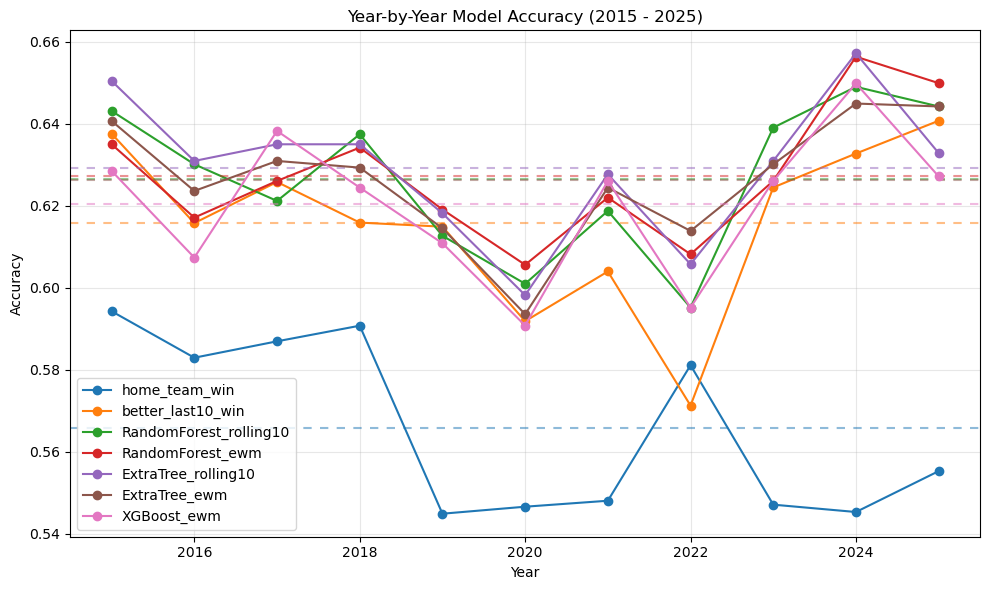

In [133]:
# Exclude the mean/std summary rows, keep only the year-indexed rows
plot_df = final_accuracy_df.drop(index=['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 6))

for col in plot_df.columns:
    line = ax.plot(plot_df.index, plot_df[col], marker='o', label=col)[0]
    ax.axhline(final_accuracy_df.loc['mean', col], color=line.get_color(), dashes=[4, 4], alpha=0.5)


ax.set_xlabel('Year')
ax.set_ylabel('Accuracy')
ax.set_title('Year-by-Year Model Accuracy (2015 - 2025)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
# plt.xticks(plot_df.index, rotation=45)
plt.tight_layout()
plt.show()